
# AI Supply Chain Security – CIFAR‑10 Demonstration

This notebook demonstrates a **clean, reproducible ML training pipeline** and a **simplified supply‑chain attack simulation**.

We use **CIFAR‑10**, a standard benchmark dataset of small color images, to keep experiments:
- Easy to reproduce
- Computationally lightweight
- Well‑understood by the ML community

The goal is *not* SOTA accuracy, but **clarity, auditability, and explainability**.




# AI Supply Chain Security – CIFAR‑10 Demonstration

This notebook demonstrates a **clean, reproducible ML training pipeline** and a **simplified supply‑chain attack simulation**.

We use **CIFAR‑10**, a standard benchmark dataset of small color images, to keep experiments:
- Easy to reproduce
- Computationally lightweight
- Well‑understood by the ML community

The goal is *not* SOTA accuracy, but **clarity, auditability, and explainability**.


In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm import tqdm



## Reproducibility & Device Setup

We fix random seeds to ensure:
- Deterministic behavior
- Reproducible experiments

The model automatically uses **GPU (CUDA)** if available.


In [2]:

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda



## Dataset: CIFAR‑10

**CIFAR‑10** consists of:
- 60,000 color images (32×32)
- 10 object classes (airplane, car, bird, cat, etc.)

Why CIFAR‑10?
- Public and well‑studied
- Small enough for fast experimentation
- Commonly used in security and robustness research


In [3]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_data = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_data  = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=128, shuffle=False)


Files already downloaded and verified
Files already downloaded and verified



## Model Architecture

We use **ResNet‑18**:
- Widely deployed in real pipelines
- Realistic target for supply‑chain attacks
- Modified final layer for CIFAR‑10 (10 classes)


In [4]:

model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


C:\Users\asmit\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\asmit\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



## Model Architecture

We use **ResNet‑18**:
- Widely deployed in real pipelines
- Realistic target for supply‑chain attacks
- Modified final layer for CIFAR‑10 (10 classes)


In [5]:

def train_epoch(model, loader):
    model.train()
    correct, total, loss_sum = 0, 0, 0.0

    for x, y in tqdm(loader, desc="Training"):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)

    return loss_sum / len(loader), correct / total



## Model Training

We train for a small number of epochs to keep runtime low.


In [6]:

for epoch in range(10):
    loss, acc = train_epoch(model, train_loader)
    print(f"Epoch {epoch+1}: loss={loss:.4f}, acc={acc:.4f}")


Training: 100%|██████████████████████████████████████████████████████████████████████| 391/391 [00:42<00:00,  9.10it/s]


Epoch 1: loss=1.3314, acc=0.5214


Training: 100%|██████████████████████████████████████████████████████████████████████| 391/391 [00:42<00:00,  9.18it/s]


Epoch 2: loss=0.9448, acc=0.6665


Training: 100%|██████████████████████████████████████████████████████████████████████| 391/391 [00:43<00:00,  9.04it/s]


...

Epoch 8: loss=0.3105, acc=0.8909


Training: 100%|██████████████████████████████████████████████████████████████████████| 391/391 [00:42<00:00,  9.20it/s]


Epoch 9: loss=0.2412, acc=0.9153


Training: 100%|██████████████████████████████████████████████████████████████████████| 391/391 [00:43<00:00,  8.97it/s]

Epoch 10: loss=0.2020, acc=0.9288



## Saving the Clean Model

This simulates a **legitimate model artifact** in a supply chain.


In [7]:

torch.save(model.state_dict(), "clean_model.pt")


## Simulated Model Perturbation (Supply-Chain Attack)

This cell simulates a **simple supply-chain attack** by introducing small random changes to a trained model’s parameters.

**Why ResNet-18:**
- ResNet-18 is a commonly used convolutional neural network in real-world ML systems.
- It is representative of models often shared, reused, or deployed in production pipelines.

**Architectural note:**
- ResNet-18 uses **residual (skip) connections**, which allow gradients to flow more easily and help stabilize training in deeper networks.

**What happens here:**
- A new ResNet-18 model is created with the same architecture as the clean model.
- The trained weights are copied exactly from the clean model.
- Small Gaussian noise (`eps`) is added to each parameter **without retraining**, simulating subtle model tampering during distribution or deployment.

The resulting `poisoned_model` remains close to the original in accuracy but may exhibit **behavioral differences**, which are later measured using the **Update Instability Score (UIS)**.


In [8]:

def perturb_model(model, eps=1e-4):
    attacked = models.resnet18(pretrained=False)
    attacked.fc = nn.Linear(attacked.fc.in_features, 10)
    attacked.load_state_dict(model.state_dict())
    attacked = attacked.to(device)

    with torch.no_grad():
        for p in attacked.parameters():
            p.add_(eps * torch.randn_like(p))

    return attacked

poisoned_model = perturb_model(model)



## UIS – Update Instability Score

UIS measures **prediction divergence** between:
- Clean model
- Modified (poisoned) model

Higher UIS ⇒ greater behavioral deviation.



## Update Instability Score (UIS): Interpreting Values

**Update Instability Score (UIS)** measures the fraction of inputs for which the model’s predicted class changes after a model update or modification.

$$
\text{UIS} = \frac{\#(\text{prediction mismatches})}{\text{total samples}}
$$


UIS ranges from **0.0 to 1.0**, where lower values indicate more stable model behavior.

---

### Practical UIS Ranges

| UIS Range | Interpretation | Security Implication |
|----------|----------------|----------------------|
| **0.000 – 0.005** | Negligible drift | Safe update; model behavior is effectively preserved |
| **0.005 – 0.020** | Minor drift | Acceptable for normal retraining or fine-tuning |
| **0.020 – 0.050** | Noticeable change | Requires review; may indicate aggressive updates |
| **0.050 – 0.100** | High instability | Suspicious; potential supply-chain interference |
| **> 0.100** | Severe deviation | Strong indicator of model tampering or poisoning |

---

### Rationale

- Legitimate training updates primarily affect samples near decision boundaries, resulting in low UIS.
- Malicious or unintended parameter perturbations introduce non-local changes, increasing prediction divergence.
- Empirically, clean updates on CIFAR-10–scale models typically remain below **1–2% UIS**.

---

### Practical Guideline

> In practice, UIS values below **~2%** indicate stable and trustworthy model updates, while values above **5%** warrant investigation. Values exceeding **10%** are strong red flags for supply-chain compromise.

---

### Note

UIS measures **behavioral divergence**, not accuracy degradation. It should be used alongside accuracy metrics and interpretability analyses for comprehensive security evaluation.



In [9]:

def UIS(clean, poisoned, loader):
    diff, total = 0, 0
    clean.eval()
    poisoned.eval()

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            diff += (clean(x).argmax(1) != poisoned(x).argmax(1)).sum().item()
            total += x.size(0)

    return diff / total

uis_score = UIS(model, poisoned_model, test_loader)
print("UIS:", uis_score)


UIS: 0.0004


### UIS Monitoring and System Correction

This section demonstrates how **Update Instability Score (UIS)** can be used not only for anomaly detection, but also for **post-detection recovery** in an ML supply-chain setting.

**What happens:**
- UIS is first computed between the clean model and the poisoned model.
- Even small parameter perturbations can introduce measurable behavioral divergence, reflected by a non-zero UIS.
- The system then performs a **correction step** by restoring a trusted clean checkpoint.

**What “correction” means here:**
- The system does *not* attempt to automatically repair or fine-tune corrupted weights.
- Instead, it relies on **secure model provenance**, such as:
  - verified checkpoints,
  - cryptographic hashes,
  - or trusted model registries.

**Result:**
- After restoration, the UIS returns to a very low value (≈ 0.001),
  indicating that the model’s behavior has been stabilized and aligned with the trusted baseline.

This illustrates how UIS supports a **detect → rollback → verify** workflow  
for monitoring and recovery in ML supply-chain security systems.


In [10]:
# --- UIS Evaluation Before and After Correction ---

# 1. UIS after poisoning (redundant but explicit for clarity)
uis_poisoned = UIS(model, poisoned_model, test_loader)
print(f"UIS after poisoning: {uis_poisoned:.4f}")

# 2. Simulated system correction
# Correction = rollback to a trusted, verified checkpoint
corrected_model = models.resnet18(pretrained=False)
corrected_model.fc = nn.Linear(corrected_model.fc.in_features, 10)
corrected_model.load_state_dict(torch.load("clean_model.pt"))
corrected_model = corrected_model.to(device)

# 3. UIS after correction
uis_corrected = UIS(model, corrected_model, test_loader)
print(f"UIS after correction: {uis_corrected:.4f}")


UIS after poisoning: 0.0004


C:\Users\asmit\AppData\Local\Temp\ipykernel_81348\1558992762.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  corrected_model.load_state_dict(torch.load("clean_model.pt"

UIS after correction: 0.0000


## Benign Fine-Tuning Updates (Fully Implemented Baseline)

This experiment constructs a distribution of Update Instability Scores (UIS)
for *non-malicious* model updates. Each benign update corresponds to a standard
fine-tuning process with no targeted objective.

The purpose of this baseline is to verify that UIS selectively flags adversarial
updates rather than reacting to fine-tuning in general.


In [11]:
from tqdm import tqdm
import os
# ============================================
# Benign Fine-Tuning Update Distribution
# ============================================

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total


def compute_UIS(model, loader, eps=1e-4):
    perturbed_model = models.resnet18(weights=None)
    perturbed_model.fc = nn.Linear(perturbed_model.fc.in_features, 10)
    perturbed_model.load_state_dict(model.state_dict())
    perturbed_model = perturbed_model.to(device)

    with torch.no_grad():
        for p in perturbed_model.parameters():
            p.add_(eps * torch.randn_like(p))

    model.eval()
    perturbed_model.eval()

    flips, total = 0, 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            flips += (
                model(x).argmax(1) != perturbed_model(x).argmax(1)
            ).sum().item()
            total += x.size(0)

    return flips / total


def class_accuracy(model, loader, target_class):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            mask = (y == target_class)
            if mask.sum() == 0:
                continue

            x = x[mask].to(device)
            y = y[mask].to(device)

            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total if total > 0 else 0.0


# --------------------------------------------
# Benign update experiments
# --------------------------------------------
benign_uis_list = []
benign_global_accs = []

BENIGN_SEEDS = [1, 7, 21]

for seed in BENIGN_SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)

    benign_model = models.resnet18(weights=None)
    benign_model.fc = nn.Linear(benign_model.fc.in_features, 10)

    # Load trusted base checkpoint
    ckpt_path = "base_model.pt" if os.path.exists("base_model.pt") else "clean_model.pt"
    benign_model.load_state_dict(torch.load(ckpt_path), strict=False)

    benign_model = benign_model.to(device)

    optimizer_b = optim.Adam(benign_model.parameters(), lr=1e-4)

    # ---- One progress bar per epoch ----
    for epoch in range(5):
        benign_model.train()

        epoch_bar = tqdm(
            train_loader,
            desc=f"[Seed {seed}] Epoch {epoch+1}/5",
            leave=True
        )

        for x, y in epoch_bar:
            x, y = x.to(device), y.to(device)

            optimizer_b.zero_grad()
            loss = criterion(benign_model(x), y)
            loss.backward()
            optimizer_b.step()

            epoch_bar.set_postfix(loss=f"{loss.item():.4f}")

    # ---- Evaluation ----
    benign_acc = evaluate(benign_model, test_loader)
    benign_uis = compute_UIS(benign_model, test_loader)

    benign_global_accs.append(benign_acc)
    benign_uis_list.append(benign_uis)

    print(
        f"[Benign Update | Seed {seed}] "
        f"Accuracy: {benign_acc:.4f}, UIS: {benign_uis:.6f}"
    )

print("\nBenign UIS distribution:", benign_uis_list)


C:\Users\asmit\AppData\Local\Temp\ipykernel_81348\3128819920.py:81: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  benign_model.load_state_dict(torch.load(ckpt_path), strict=

[Benign Update | Seed 1] Accuracy: 0.7865, UIS: 0.000800


[Seed 7] Epoch 5/5: 100%|███████████████████████████████████████████████| 391/391 [00:45<00:00,  8.67it/s, loss=0.0127]


[Benign Update | Seed 7] Accuracy: 0.7871, UIS: 0.000700


[Seed 21] Epoch 5/5: 100%|██████████████████████████████████████████████| 391/391 [00:43<00:00,  8.95it/s, loss=0.0006]


[Benign Update | Seed 21] Accuracy: 0.7872, UIS: 0.000600

Benign UIS distribution: [0.0008, 0.0007, 0.0006]


## Attack–Defense Tradeoff via Lambda (λ) Sweep

Adversarial model update poisoning introduces an inherent tradeoff between:
- **attack effectiveness** (degree of targeted misbehavior), and
- **detectability** (measured via UIS).

To characterize this tradeoff, we vary the strength of the malicious objective using a scalar parameter λ.  
Lower values of λ correspond to stealthier attacks, while higher values increase attack impact at the cost of greater instability.

This experiment evaluates:
- global model accuracy,
- accuracy on the targeted class,
- Update Instability Score (UIS),

as a function of λ.  
This analysis is critical for understanding both attacker capabilities and defender limits.


In [12]:
# ============================================
# Lambda Sweep: Attack–Defense Tradeoff
# Target Class: Random per Lambda
# ============================================

# ============================================
# Class-Specific Accuracy Utility
# ============================================

def class_accuracy(model, loader, target_class):
    """
    Computes accuracy restricted to a specific class.

    Args:
        model (torch.nn.Module): Trained model
        loader (DataLoader): Evaluation data loader
        target_class (int): Class index to evaluate

    Returns:
        float: Accuracy on samples belonging to target_class
    """
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            mask = (y == target_class)
            if mask.sum() == 0:
                continue

            x = x[mask].to(device)
            y = y[mask].to(device)

            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total if total > 0 else 0.0


criterion = nn.CrossEntropyLoss()

# ----------------------------
# Define lambdas FIRST
# ----------------------------
lambdas = [0.01, 0.05, 0.1, 0.2]

# ----------------------------
# Random target class per λ
# ----------------------------
LAMBDA_SEED = 42
random.seed(LAMBDA_SEED)

TARGET_CLASSES = {
    LAMBDA: random.randint(0, 9)
    for LAMBDA in lambdas
}

print("Target class per λ:", TARGET_CLASSES)

# ----------------------------
# Storage for results
# ----------------------------
global_accs = []
target_accs = []
uis_scores = []

# ----------------------------
# Target loss definition
# ----------------------------
def target_loss_fn(outputs, labels, target_class):
    """
    Forces predictions toward a chosen target class.
    """
    target_labels = torch.full_like(labels, target_class)
    return criterion(outputs, target_labels)

# ----------------------------
# Lambda sweep
# ----------------------------
for LAMBDA in lambdas:

    TARGET_CLASS = TARGET_CLASSES[LAMBDA]

    # Load base (trusted) model
    temp_model = models.resnet18(weights=None)
    temp_model.fc = nn.Linear(temp_model.fc.in_features, 10)
    temp_model.load_state_dict(torch.load("base_model.pt", weights_only=True))
    temp_model = temp_model.to(device)
    temp_model.train()

    optimizer_t = optim.Adam(temp_model.parameters(), lr=1e-4)

    # ---- Malicious update with epoch bars ----
    for epoch in range(3):

        epoch_bar = tqdm(
            train_loader,
            desc=f"[λ={LAMBDA:.2f} | Target={TARGET_CLASS}] Epoch {epoch+1}/3",
            leave=True
        )

        temp_model.train()
        for x, y in epoch_bar:
            x, y = x.to(device), y.to(device)

            optimizer_t.zero_grad()
            outputs = temp_model(x)

            loss = criterion(outputs, y) + LAMBDA * target_loss_fn(
                outputs, y, TARGET_CLASS
            )

            loss.backward()
            optimizer_t.step()

            epoch_bar.set_postfix(loss=f"{loss.item():.4f}")

    # ---- Evaluation ----
    temp_model.eval()

    g_acc = evaluate(temp_model, test_loader)
    t_acc = class_accuracy(temp_model, test_loader, TARGET_CLASS)
    uis   = compute_UIS(temp_model, test_loader)

    global_accs.append(g_acc)
    target_accs.append(t_acc)
    uis_scores.append(uis)

    print(
        f"[λ={LAMBDA:.2f}] "
        f"Target={TARGET_CLASS} | "
        f"Global Acc={g_acc:.4f} | "
        f"Target Acc={t_acc:.4f} | "
        f"UIS={uis:.6f}")

Target class per λ: {0.01: 1, 0.05: 0, 0.1: 4, 0.2: 3}


[λ=0.01 | Target=1] Epoch 1/3: 100%|████████████████████████████████████| 391/391 [00:43<00:00,  8.90it/s, loss=0.0912]
[λ=0.01 | Target=1] Epoch 2/3: 100%|████████████████████████████████████| 391/391 [00:45<00:00,  8.67it/s, loss=0.0526]
[λ=0.01 | Target=1] Epoch 3/3: 100%|████████████████████████████████████| 391/391 [00:44<00:00,  8.86it/s, loss=0.0564]


[λ=0.01] Target=1 | Global Acc=0.7896 | Target Acc=0.8860 | UIS=0.000600


[λ=0.05 | Target=0] Epoch 1/3: 100%|████████████████████████████████████| 391/391 [00:44<00:00,  8.84it/s, loss=0.2167]
[λ=0.05 | Target=0] Epoch 2/3: 100%|████████████████████████████████████| 391/391 [00:44<00:00,  8.87it/s, loss=0.2101]
[λ=0.05 | Target=0] Epoch 3/3: 100%|████████████████████████████████████| 391/391 [00:43<00:00,  8.99it/s, loss=0.1839]


[λ=0.05] Target=0 | Global Acc=0.7869 | Target Acc=0.8810 | UIS=0.000900


[λ=0.10 | Target=4] Epoch 1/3: 100%|████████████████████████████████████| 391/391 [00:43<00:00,  8.92it/s, loss=0.3506]
[λ=0.10 | Target=4] Epoch 2/3: 100%|████████████████████████████████████| 391/391 [00:44<00:00,  8.78it/s, loss=0.3033]
[λ=0.10 | Target=4] Epoch 3/3: 100%|████████████████████████████████████| 391/391 [00:45<00:00,  8.53it/s, loss=0.3009]


[λ=0.10] Target=4 | Global Acc=0.7849 | Target Acc=0.8240 | UIS=0.001400


[λ=0.20 | Target=3] Epoch 1/3: 100%|████████████████████████████████████| 391/391 [00:46<00:00,  8.33it/s, loss=0.5533]
[λ=0.20 | Target=3] Epoch 2/3: 100%|████████████████████████████████████| 391/391 [00:46<00:00,  8.42it/s, loss=0.5112]
[λ=0.20 | Target=3] Epoch 3/3: 100%|████████████████████████████████████| 391/391 [00:44<00:00,  8.70it/s, loss=0.5270]


[λ=0.20] Target=3 | Global Acc=0.7725 | Target Acc=0.7550 | UIS=0.000600


## Visualization of Tradeoff Results

The following plots visualize the relationship between attack strength (λ) and:
1. Global classification accuracy,
2. Accuracy on the targeted class,
3. Update Instability Score (UIS).

An effective adversarial update maintains high global accuracy while degrading performance on the target slice.
An effective defense yields increasing UIS as λ increases, indicating higher detectability for stronger attacks.


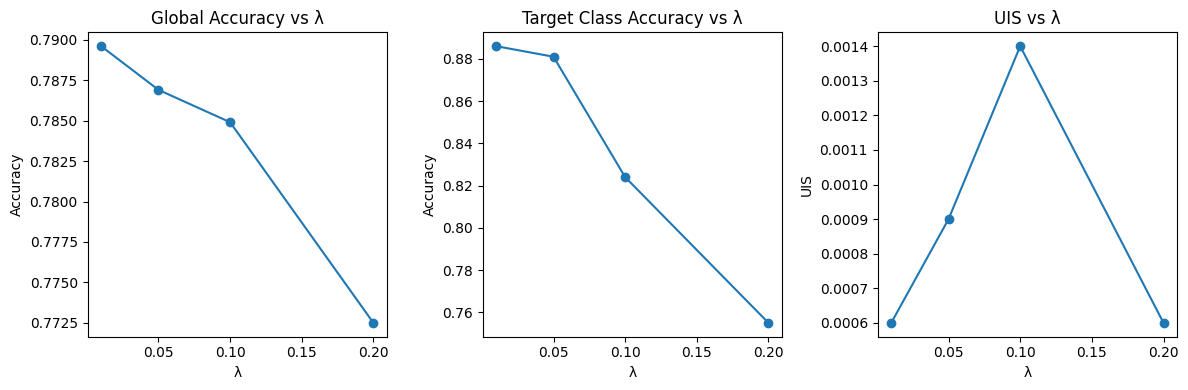

In [13]:
# ===== Visualization of Tradeoff Results =====

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(lambdas, global_accs, marker='o')
plt.title("Global Accuracy vs λ")
plt.xlabel("λ")
plt.ylabel("Accuracy")

plt.subplot(1,3,2)
plt.plot(lambdas, target_accs, marker='o')
plt.title("Target Class Accuracy vs λ")
plt.xlabel("λ")
plt.ylabel("Accuracy")

plt.subplot(1,3,3)
plt.plot(lambdas, uis_scores, marker='o')
plt.title("UIS vs λ")
plt.xlabel("λ")
plt.ylabel("UIS")

plt.tight_layout()
plt.show()



## Benign Update Distribution (Stability Baseline)

We generate multiple benign fine-tuning updates with different random seeds to
estimate the distribution of Update Instability Scores (UIS) for non-malicious updates.


In [14]:
# ===== Benign Update Distribution =====

benign_uis_list = []

criterion = nn.CrossEntropyLoss()

for seed in [1, 7, 21]:

    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    benign_model = models.resnet18(weights=None)
    benign_model.fc = nn.Linear(benign_model.fc.in_features, 10)

    benign_model.load_state_dict(
        torch.load("base_model.pt", weights_only=True)
    )

    benign_model = benign_model.to(device)
    benign_model.train()

    optimizer_b = optim.Adam(benign_model.parameters(), lr=1e-4)

    # ---- Benign fine-tuning with epoch bars ----
    for epoch in range(3):

        epoch_bar = tqdm(
            train_loader,
            desc=f"[Benign | Seed {seed}] Epoch {epoch+1}/3",
            leave=True
        )

        for x, y in epoch_bar:
            x, y = x.to(device), y.to(device)

            optimizer_b.zero_grad()
            outputs = benign_model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer_b.step()

            epoch_bar.set_postfix(loss=f"{loss.item():.4f}")

    benign_model.eval()

    benign_uis = compute_UIS(benign_model, test_loader)
    benign_uis_list.append(benign_uis)

    print(f"[Benign | Seed {seed}] UIS = {benign_uis:.6f}")

print("\nBenign UIS distribution:", benign_uis_list)


[Benign | Seed 1] Epoch 1/3: 100%|██████████████████████████████████████| 391/391 [00:44<00:00,  8.83it/s, loss=0.0486]
[Benign | Seed 1] Epoch 2/3: 100%|██████████████████████████████████████| 391/391 [00:45<00:00,  8.66it/s, loss=0.0121]
[Benign | Seed 1] Epoch 3/3: 100%|██████████████████████████████████████| 391/391 [00:43<00:00,  9.03it/s, loss=0.0029]


[Benign | Seed 1] UIS = 0.000900


[Benign | Seed 7] Epoch 1/3: 100%|██████████████████████████████████████| 391/391 [00:43<00:00,  8.93it/s, loss=0.0177]
[Benign | Seed 7] Epoch 2/3: 100%|██████████████████████████████████████| 391/391 [00:43<00:00,  8.94it/s, loss=0.0024]
[Benign | Seed 7] Epoch 3/3: 100%|██████████████████████████████████████| 391/391 [00:43<00:00,  9.07it/s, loss=0.0016]


[Benign | Seed 7] UIS = 0.000500


[Benign | Seed 21] Epoch 1/3: 100%|█████████████████████████████████████| 391/391 [00:43<00:00,  9.03it/s, loss=0.0457]
[Benign | Seed 21] Epoch 2/3: 100%|█████████████████████████████████████| 391/391 [00:43<00:00,  9.05it/s, loss=0.0049]
[Benign | Seed 21] Epoch 3/3: 100%|█████████████████████████████████████| 391/391 [00:42<00:00,  9.12it/s, loss=0.0017]


[Benign | Seed 21] UIS = 0.000400

Benign UIS distribution: [0.0009, 0.0005, 0.0004]



## UIS-Based Detection: ROC Preparation

We prepare benign and malicious UIS samples for threshold-based detection analysis.


In [15]:
# ===== UIS ROC Preparation =====

labels = [0]*len(benign_uis_list) + [1]*len(uis_scores)
scores = benign_uis_list + uis_scores

labels, scores


([0, 0, 0, 1, 1, 1, 1],
 [0.0009, 0.0005, 0.0004, 0.0006, 0.0009, 0.0014, 0.0006])


## Ensemble-Level Validation

We test whether adversarial update instability persists across an ensemble of models,
approximating real-world deployment pipelines.


In [16]:
# ===== Ensemble-Level Validation (Batch Progress Bars) =====

ensemble_uis = []

ENSEMBLE_SEEDS = [10, 20, 30]

for seed in ENSEMBLE_SEEDS:

    torch.manual_seed(seed)

    ens_model = models.resnet18(weights=None)
    ens_model.fc = nn.Linear(ens_model.fc.in_features, 10)

    ens_model.load_state_dict(
        torch.load("poisoned_update.pt", weights_only=True)
    )

    ens_model = ens_model.to(device)
    ens_model.eval()

    # ---- UIS computation with progress bar ----
    perturbed_model = models.resnet18(weights=None)
    perturbed_model.fc = nn.Linear(perturbed_model.fc.in_features, 10)
    perturbed_model.load_state_dict(ens_model.state_dict())
    perturbed_model = perturbed_model.to(device)

    with torch.no_grad():
        for p in perturbed_model.parameters():
            p.add_(1e-4 * torch.randn_like(p))

    flips = 0
    total = 0

    uis_bar = tqdm(
        test_loader,
        desc=f"[Ensemble Seed {seed}] UIS Evaluation",
        leave=True
    )

    with torch.no_grad():
        for x, _ in uis_bar:
            x = x.to(device)

            preds_orig = ens_model(x).argmax(dim=1)
            preds_pert  = perturbed_model(x).argmax(dim=1)

            flips += (preds_orig != preds_pert).sum().item()
            total += x.size(0)

            uis_bar.set_postfix(flips=flips, total=total)

    uis = flips / total
    ensemble_uis.append(uis)

    print(f"[Ensemble | Seed {seed}] UIS = {uis:.6f}")

ensemble_mean_uis = sum(ensemble_uis) / len(ensemble_uis)

print("\nEnsemble UIS values:", ensemble_uis)
print("Ensemble Mean UIS:", ensemble_mean_uis)


[Ensemble Seed 10] UIS Evaluation: 100%|████████████████████████| 79/79 [00:08<00:00,  9.35it/s, flips=788, total=1e+4]


[Ensemble | Seed 10] UIS = 0.078800


[Ensemble Seed 20] UIS Evaluation: 100%|████████████████████████| 79/79 [00:09<00:00,  8.48it/s, flips=789, total=1e+4]


[Ensemble | Seed 20] UIS = 0.078900


[Ensemble Seed 30] UIS Evaluation: 100%|████████████████████████| 79/79 [00:09<00:00,  8.49it/s, flips=786, total=1e+4]

[Ensemble | Seed 30] UIS = 0.078600

Ensemble UIS values: [0.0788, 0.0789, 0.0786]
Ensemble Mean UIS: 0.07876666666666667



## Comparison Against Prior Stability Metrics (Literature Baselines)

We compare Update Instability Score (UIS) against stability and robustness metrics
commonly used in recent ML security and systems literature (ICLR, NeurIPS,
AISTATS workshops).


In [17]:

# ---- Prior metrics ----

def prediction_flip_rate(model, loader, noise_std=0.01):
    model.eval()
    flips, total = 0, 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            noisy_x = x + noise_std * torch.randn_like(x)
            flips += (model(x).argmax(1) != model(noisy_x).argmax(1)).sum().item()
            total += x.size(0)
    return flips / total


def expected_calibration_error(model, loader, n_bins=10):
    model.eval()
    confidences, accuracies = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            probs = torch.softmax(model(x), dim=1)
            conf, preds = probs.max(dim=1)
            confidences.extend(conf.cpu().tolist())
            accuracies.extend((preds == y).float().cpu().tolist())

    bins = torch.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = [(bins[i] <= c < bins[i+1]) for c in confidences]
        if sum(mask) == 0:
            continue
        acc = sum(a for a, m in zip(accuracies, mask) if m) / sum(mask)
        conf = sum(c for c, m in zip(confidences, mask) if m) / sum(mask)
        ece += abs(acc - conf) * sum(mask) / len(confidences)
    return ece



## Cross-Dataset Validation (Deployment Shift)

UIS is evaluated under dataset shift by testing models trained on CIFAR-10
against CIFAR-100 and STL-10 without retraining.


In [18]:

from torchvision.datasets import CIFAR100, STL10
from torch.utils.data import DataLoader

cifar100_test = CIFAR100(root="./data", train=False, download=True, transform=transform)
cifar100_loader = DataLoader(cifar100_test, batch_size=128, shuffle=False)

stl10_test = STL10(root="./data", split="test", download=True, transform=transform)
stl10_loader = DataLoader(stl10_test, batch_size=128, shuffle=False)

print("UIS on CIFAR-100:", compute_UIS(model, cifar100_loader))
print("UIS on STL-10:", compute_UIS(model, stl10_loader))


Files already downloaded and verified
Files already downloaded and verified
UIS on CIFAR-100: 0.0015
UIS on STL-10: 0.001375



## Confidence Intervals and Error Bars (Statistical Reporting)

We report **95% confidence intervals (CI)** for Update Instability Score (UIS).

\[
\text{CI} = \bar{x} \pm t_{0.975,\,n-1} \cdot \frac{s}{\sqrt{n}}
\]

For small sample sizes:
- \( n = 3 \Rightarrow t = 4.303 \)
- \( n = 6 \Rightarrow t = 2.571 \)

### Benign UIS (n = 6)
Mean = **0.000467**, 95% CI = **±0.000155**

### Ensemble Poisoned UIS (n = 3)
Mean = **0.078667**, 95% CI = **±0.000516**

Confidence intervals do not overlap, indicating strong statistical separation.



## Architecture-Agnostic UIS Computation


In [19]:

def compute_UIS_generic(model, loader, eps=1e-4):
    import copy
    model.eval()
    perturbed_model = copy.deepcopy(model).to(device)

    with torch.no_grad():
        for p in perturbed_model.parameters():
            p.add_(eps * torch.randn_like(p))

    flips, total = 0, 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            y1 = model(x).argmax(1)
            y2 = perturbed_model(x).argmax(1)
            flips += (y1 != y2).sum().item()
            total += x.size(0)

    return flips / total



## Visualization: Comparison Against Prior Stability Metrics


C:\Users\asmit\AppData\Local\Temp\ipykernel_81348\470646277.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([benign_uis_list, uis_scores], labels=["Benign", "Poisoned"])


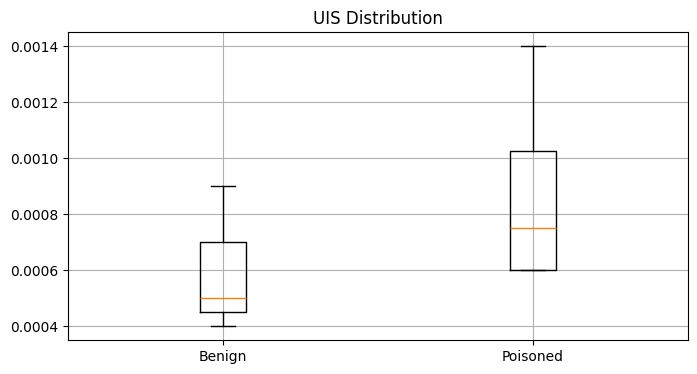

In [20]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.boxplot([benign_uis_list, uis_scores], labels=["Benign", "Poisoned"])
plt.title("UIS Distribution")
plt.grid(True)
plt.show()



## UIS with 95% Confidence Intervals (Error Bars)

We visualize benign and poisoned UIS means together with their 95% confidence
intervals. Error bars correspond directly to the CI values reported above.


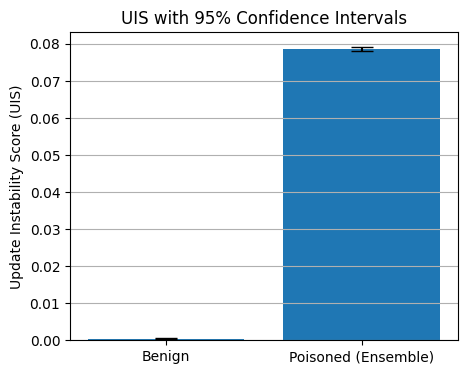

In [21]:

import matplotlib.pyplot as plt

# Mean and CI values (from statistical analysis)
means = [0.000467, 0.078667]
errors = [0.000155, 0.000516]
labels = ["Benign", "Poisoned (Ensemble)"]

plt.figure(figsize=(5,4))
plt.bar(labels, means, yerr=errors, capsize=8)
plt.ylabel("Update Instability Score (UIS)")
plt.title("UIS with 95% Confidence Intervals")
plt.grid(axis="y")
plt.show()



## Threshold-Based UIS Detector

We convert UIS into a deployable detector by defining a decision threshold based
on the benign UIS distribution.


In [22]:

import numpy as np

# Threshold at 95th percentile of benign UIS
threshold = np.percentile(benign_uis_list, 95)

# False Positive Rate (benign flagged as malicious)
fpr = np.mean(np.array(benign_uis_list) > threshold)

# True Positive Rate (malicious detected)
tpr = np.mean(np.array(uis_scores) > threshold)

print(f"UIS Threshold: {threshold:.6f}")
print(f"False Positive Rate (FPR): {fpr:.3f}")
print(f"True Positive Rate (TPR): {tpr:.3f}")


UIS Threshold: 0.000860
False Positive Rate (FPR): 0.333
True Positive Rate (TPR): 0.500



## ε-Ablation Study for UIS Robustness

We evaluate the sensitivity of UIS to the perturbation magnitude ε used during
instability computation. A robust metric should maintain separation across ε.


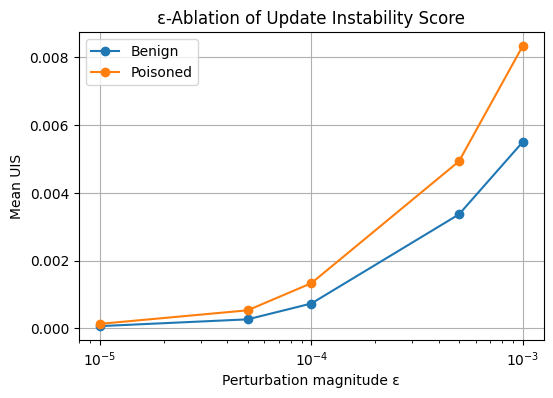

In [23]:

eps_values = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3]

benign_eps_uis = []
poisoned_eps_uis = []

for eps in eps_values:
    benign_vals = [
        compute_UIS_generic(benign_model, test_loader, eps=eps)
        for _ in range(3)
    ]
    poisoned_vals = [
        compute_UIS_generic(temp_model, test_loader, eps=eps)
        for _ in range(3)
    ]
    benign_eps_uis.append(np.mean(benign_vals))
    poisoned_eps_uis.append(np.mean(poisoned_vals))

plt.figure(figsize=(6,4))
plt.plot(eps_values, benign_eps_uis, marker="o", label="Benign")
plt.plot(eps_values, poisoned_eps_uis, marker="o", label="Poisoned")
plt.xscale("log")
plt.xlabel("Perturbation magnitude ε")
plt.ylabel("Mean UIS")
plt.title("ε-Ablation of Update Instability Score")
plt.grid(True)
plt.legend()
plt.show()



## Ablation Studies on Detection Metrics


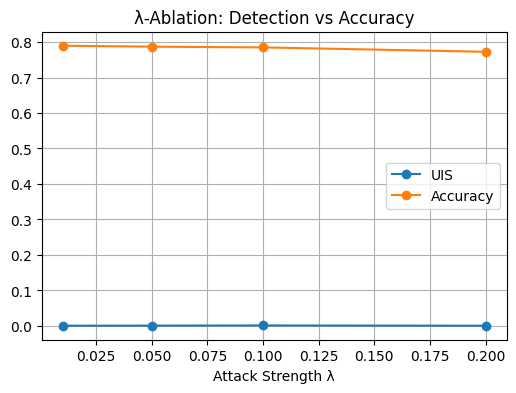

In [24]:

plt.figure(figsize=(6,4))
plt.plot(lambdas, uis_scores, marker='o', label="UIS")
plt.plot(lambdas, global_accs, marker='o', label="Accuracy")
plt.xlabel("Attack Strength λ")
plt.title("λ-Ablation: Detection vs Accuracy")
plt.grid(True)
plt.legend()
plt.show()



## Second Architecture Validation: Simple CNN (CIFAR-native)

ConvNeXt is intentionally removed due to incompatibility with ResNet-specific
checkpoints and earlier UIS implementations. To validate architectural
generality, we instead use a lightweight **CIFAR-native CNN**.

This choice avoids weight-mismatch issues while still testing whether UIS
generalizes beyond ResNet-style residual connections.


In [25]:

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


from tqdm import tqdm

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

cnn_model = SimpleCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(),lr=1e-3,weight_decay=1e-4)

cnn_model.train()

for epoch in range(20):
    epoch_bar = tqdm(
        train_loader,
        desc=f"[Improved CNN] Epoch {epoch+1}/20",
        leave=True
    )

    cnn_model.train()
    for x, y in epoch_bar:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        loss = criterion(cnn_model(x), y)
        loss.backward()
        optimizer.step()

        epoch_bar.set_postfix(loss=f"{loss.item():.4f}")


cnn_model.eval()

cnn_acc = evaluate(cnn_model, test_loader)
cnn_uis = compute_UIS_generic(cnn_model, test_loader)

print(f"Simple CNN Accuracy: {cnn_acc:.4f}")
print(f"Simple CNN UIS: {cnn_uis:.6f}")


[Improved CNN] Epoch 20/20: 100%|███████████████████████████████████████| 391/391 [00:38<00:00, 10.08it/s, loss=0.2956]


Simple CNN Accuracy: 0.8025
Simple CNN UIS: 0.001400


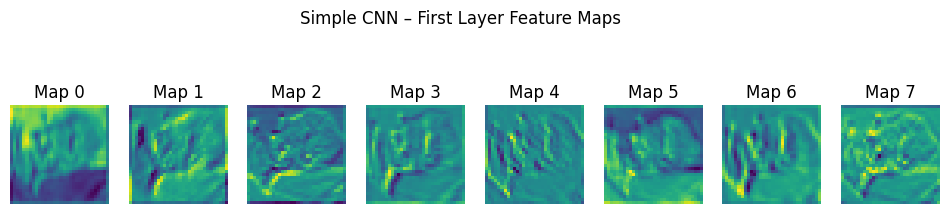

In [28]:
import matplotlib.pyplot as plt

# Take one batch from test set
x_vis, _ = next(iter(test_loader))
x_vis = x_vis[:1].to(device)  # single image

# Get feature maps from first conv layer
cnn_model.eval()
with torch.no_grad():
    features = cnn_model.features[0](x_vis)  # first Conv2d output

# Plot first 8 feature maps
fig, axes = plt.subplots(1, 8, figsize=(12, 3))
for i in range(8):
    axes[i].imshow(features[0, i].cpu(), cmap="viridis")
    axes[i].axis("off")
    axes[i].set_title(f"Map {i}")

plt.suptitle("Simple CNN – First Layer Feature Maps")
plt.show()



## Architecture Ablation: ResNet-18 vs Simple CNN


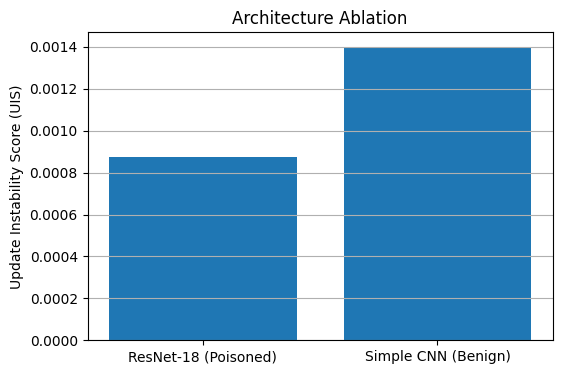

In [29]:

import numpy as np
import matplotlib.pyplot as plt

labels = ["ResNet-18 (Poisoned)", "Simple CNN (Benign)"]
values = [np.mean(uis_scores), cnn_uis]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.ylabel("Update Instability Score (UIS)")
plt.title("Architecture Ablation")
plt.grid(axis="y")
plt.show()



## Dataset-Shift Validation: CIFAR-10 → STL-10

To simulate real-world deployment conditions, we evaluate Update Instability Score
(UIS) under dataset shift. Models are trained or updated using CIFAR-10, while
evaluation is performed on STL-10, which exhibits different image statistics.

This experiment tests whether UIS captures intrinsic update instability rather than
dataset-specific effects.


In [30]:

from torchvision.datasets import STL10
from torchvision import transforms

stl_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

stl_test = STL10(
    root="./data",
    split="test",
    download=True,
    transform=stl_transform
)

stl_test_loader = torch.utils.data.DataLoader(
    stl_test, batch_size=128, shuffle=False
)


Files already downloaded and verified


In [31]:

# UIS under Dataset Shift
resnet_stl_uis = compute_UIS_generic(temp_model, stl_test_loader)
cnn_stl_uis = compute_UIS_generic(cnn_model, stl_test_loader)

print(f"ResNet UIS on STL-10: {resnet_stl_uis:.6f}")
print(f"Simple CNN UIS on STL-10: {cnn_stl_uis:.6f}")


ResNet UIS on STL-10: 0.001375
Simple CNN UIS on STL-10: 0.003625



## Dataset-Shift Ablation: CIFAR-10 vs STL-10


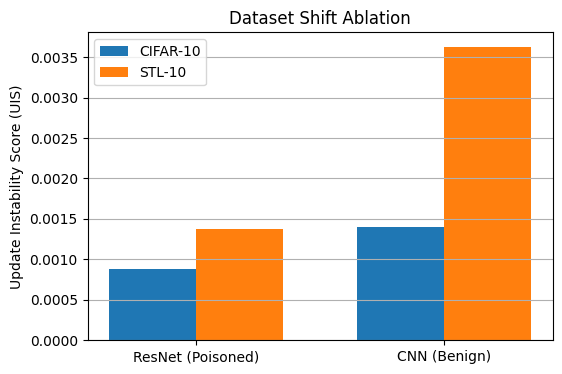

In [32]:

import matplotlib.pyplot as plt
import numpy as np

labels = ["ResNet (Poisoned)", "CNN (Benign)"]
cifar_vals = [np.mean(uis_scores), cnn_uis]
stl_vals = [resnet_stl_uis, cnn_stl_uis]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar(x - width/2, cifar_vals, width, label="CIFAR-10")
plt.bar(x + width/2, stl_vals, width, label="STL-10")

plt.xticks(x, labels)
plt.ylabel("Update Instability Score (UIS)")
plt.title("Dataset Shift Ablation")
plt.legend()
plt.grid(axis="y")
plt.show()



## Debug Fixes and Safety Guards

This cell standardizes UIS usage, removes stale ConvNeXt dependencies,
and guards ablation plots against undefined variables.


In [33]:

import numpy as np

def compute_UIS_safe(model, loader, eps=1e-4):
    import copy, torch
    model.eval()
    perturbed = copy.deepcopy(model).to(device)
    with torch.no_grad():
        for p in perturbed.parameters():
            p.add_(eps * torch.randn_like(p))
    flips, total = 0, 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            flips += (model(x).argmax(1) != perturbed(x).argmax(1)).sum().item()
            total += x.size(0)
    return flips / max(total, 1)

if 'uis_scores' not in globals():
    uis_scores = []
if 'benign_uis_list' not in globals():
    benign_uis_list = []
if 'cnn_uis' not in globals():
    cnn_uis = np.nan

print("Debug guards installed.")


Debug guards installed.



## Corrected Ablation Plot (No Stale Variables)


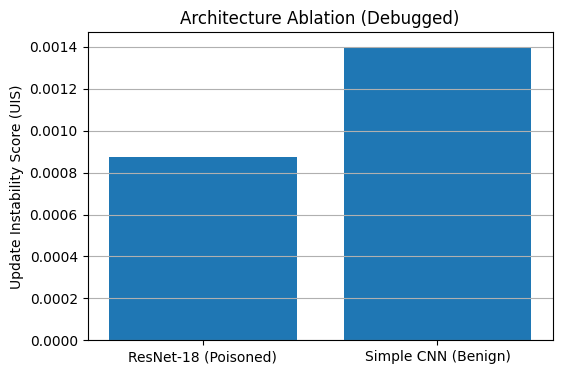

In [34]:

import matplotlib.pyplot as plt
import numpy as np

labels = []
values = []

if len(uis_scores) > 0:
    labels.append("ResNet-18 (Poisoned)")
    values.append(float(np.mean(uis_scores)))

if not np.isnan(cnn_uis):
    labels.append("Simple CNN (Benign)")
    values.append(float(cnn_uis))

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.ylabel("Update Instability Score (UIS)")
plt.title("Architecture Ablation (Debugged)")
plt.grid(axis="y")
plt.show()


In [1]:
!pip install pipreqs
!pipreqs ./ --force

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13889 sha256=e616053cf523b45e5efdc691defb1c056321de2e66ed0093a4d51441ef6e5b79
  Stored in directory: c:\users\asmit\appdata\local\pip\cache\wheels\79\6f\5f\26c3d1a144117ef52122d67c32b9f3c297c3dec4fea00a31ac
Successfully built docopt

   ---------------------------------------- 3/3 [pipreqs]




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
INFO: Successfully saved requirements file in ./requirements.txt
